<center>


<div style="display: flex; justify-content: center;">
    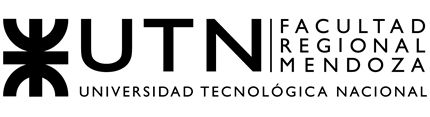
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Laboratorio n° 4: Fourier, del continuo al discreto

**Asignatura:** Análisis de Señales y Sistemas
**Requisitos previos:** Módulos 1 a 9, Laboratorios 0, 1, 2 y 3

---

## Introducción

Los tres laboratorios anteriores dejaron preguntas sin responder, y no por descuido: hacía falta una herramienta que todavía no teníamos.

En el Laboratorio 2 construiste un promediador móvil y lo llamamos **filtro**; observamos que suavizaba y que atenuaba las variaciones rápidas, pero no pudimos decir *cuáles*. Después aplicaste dos *kernels* a un par de imágenes y los llamamos **pasa-bajos** y **pasa-altos** sin ninguna justificación frecuencial: los nombres quedaron prestados. En el Laboratorio 3 enunciamos la regla del plegado —una senoide de frecuencia $f$ muestreada a $f_s$ se presenta con otra frecuencia, calculable con un resto y una reflexión—, la verificamos de oído y la usamos, pero tampoco la demostramos.

Todo eso se responde con una sola herramienta: la **transformada de Fourier**. La idea que la sostiene es que una señal puede describirse de dos maneras equivalentes. Una es la que venimos usando: *qué valor tiene en cada instante*. La otra es: *qué oscilaciones la componen y con qué intensidad cada una*. La primera descripción se llama **dominio del tiempo**; la segunda, **dominio de la frecuencia**. No son dos aproximaciones a la señal: son la misma información escrita en dos idiomas, y existe una regla exacta para traducir en ambos sentidos.

Que haya dos idiomas sería una curiosidad si no fuera por un hecho práctico: **hay problemas que en un idioma son difíciles y en el otro son casi triviales**. Convolucionar dos señales, que en el Laboratorio 2 costó bucles anidados y minutos de cálculo, en el dominio de la frecuencia es una multiplicación. Explicar por qué un promediador atenúa lo rápido requiere, en el tiempo, argumentos vagos sobre vecinos; en frecuencia es una curva que se dibuja en dos líneas.

El laboratorio tiene **dos partes**:

- La **Parte A** trabaja con señales continuas y define la transformada por su fórmula, calculándola como lo que es: una integral aproximada por una suma. Es deliberadamente lenta e ineficiente, porque el objetivo es que la definición quede clara antes de reemplazarla por una caja negra.
- La **Parte B** trabaja con señales muestreadas, que es el único caso que una computadora maneja de verdad. Ahí aparecen la **DFT** y su algoritmo rápido, la **FFT**, y con ellos el análisis de sonidos reales y un proyecto final de radio.

Al completar este laboratorio vas a poder:

- Calcular la transformada de Fourier de una señal a partir de su definición e interpretar módulo y fase por separado.
- Relacionar la duración de una señal con su ancho de banda, y un retardo temporal con una fase lineal.
- Enunciar y verificar el **teorema de convolución**, y explicar por qué convolucionar es multiplicar.
- Calcular la **respuesta en frecuencia** de un filtro discreto y decidir, a partir de ella, si es pasa-bajos o pasa-altos.
- Usar `np.fft.rfft` correctamente: elegir la duración según la resolución que necesitás y escalar el resultado para leer amplitudes.
- Explicar por qué el espectro de una señal muestreada se repite cada $f_s$, y deducir de ahí la regla de plegado del Laboratorio 3.
- Analizar el espectro de un sonido real y describir qué distingue el timbre de dos instrumentos.
- Encontrar la portadora de una señal modulada en amplitud, demodularla y recuperar el mensaje.

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Ejecutá las celdas en orden: varios ejercicios reutilizan variables y funciones definidas en ejercicios anteriores. En particular, la función que escribas en el ejercicio 1 se usa en los ejercicios 2, 3 y 4, y la del ejercicio 5 se usa en el ejercicio 8.
- Los ejercicios 9, 10 y 11 usan archivos de audio y generan sonido. Si estás en un entorno sin audio, los gráficos alcanzan para resolverlos.
- La Parte A es de cálculo y gráficos; la Parte B produce sonido. Conviene hacerlas en ese orden, pero son independientes salvo por la función del ejercicio 5.

## IMPORTANTE: qué celdas podés modificar

Este laboratorio es un **entregable**. Solo debés completar las celdas de actividad, que son las que aparecen con el comentario `# Tu código aquí` o el texto `*(Escribí tu respuesta acá)*`. Todas las demás celdas (enunciados, explicaciones, ejemplos provistos y el encabezado) **no deben modificarse**: la corrección se hace celda por celda de manera automática y alterar lo que no corresponde puede invalidar tu entrega.

Si necesitás probar algo fuera de una celda de actividad, hacelo en una copia aparte y revertí los cambios antes de entregar.

---
## Preparación

Ejecutá las dos celdas que siguen **una sola vez** al empezar.

La primera importa las librerías. A las de siempre se suman dos cosas: el módulo `signal` de SciPy, del que vamos a usar una única función en la Parte B, y `time`, para medir cuánto tarda un cálculo.

La segunda descarga los tres archivos de audio del laboratorio: dos notas instrumentales y una señal de radio. Si ya están descargados, no vuelve a bajarlos.

In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt

# Lectura de archivos .wav, igual que en los Laboratorios 2 y 3.
from scipy.io.wavfile import read

# De SciPy solo usamos, en la Parte B, la función que diseña el filtro provisto.
from scipy import signal

# Reproducción de audio dentro del notebook, igual que en los Laboratorios 1 a 3.
from IPython.display import Audio, display

print(f"Versión de NumPy: {np.__version__}")
print(f"Versión de SciPy: {signal.__name__.split('.')[0]} lista")

In [ ]:
import os
import urllib.request

URL_BASE = "https://raw.githubusercontent.com/ASyS-utn-frm/python/main/resources/audios/"
ARCHIVOS = ("nota_violin_A4.wav", "nota_flauta_A4.wav", "am_misteriosa.wav")

os.makedirs("audios", exist_ok=True)

for nombre in ARCHIVOS:
    destino = os.path.join("audios", nombre)
    if not os.path.exists(destino):
        urllib.request.urlretrieve(URL_BASE + nombre, destino)
    print(f"{destino}: {os.path.getsize(destino) / 1024:.0f} kB")

---
# Parte A — El continuo

*Señales definidas para todo instante, y su descripción en frecuencia.*

---
## Sección A: La transformada de Fourier

La transformada de Fourier de una señal $x(t)$ es la función

$$X(f) = \int_{-\infty}^{\infty} x(t)\, e^{-j 2\pi f t}\, dt$$

Conviene leerla con calma, porque la fórmula dice exactamente lo que hace.

**Qué es $e^{-j2\pi f t}$.** Es una oscilación de frecuencia $f$ escrita como número complejo. En el Módulo 2 viste que un complejo tiene parte real y parte imaginaria; acá esas dos partes son un coseno y un seno de frecuencia $f$: $e^{-j2\pi ft} = \cos(2\pi ft) - j\,\sin(2\pi ft)$. Usar una sola exponencial compleja en lugar de un par de funciones separadas es lo que permite escribir la fórmula en una línea.

**Qué hace la integral.** Multiplica la señal por esa oscilación y suma el resultado a lo largo de todo el tiempo. Si $x(t)$ contiene una oscilación de frecuencia $f$, el producto tiene un valor medio distinto de cero y la integral da un número grande. Si no la contiene, los aportes positivos y negativos se cancelan y la integral da aproximadamente cero. Es decir: **$X(f)$ mide cuánto se parece $x$ a una oscilación de frecuencia $f$**.

**Por qué el resultado es complejo.** Porque para describir una oscilación no alcanza con decir cuánta hay: hay que decir además en qué posición está. De $X(f)$, que es un número complejo, se leen las dos cosas por separado:

- El **módulo** $|X(f)|$ es *cuánto* hay de esa frecuencia. Se calcula con `np.abs`.
- La **fase** $\arg X(f)$ es *con qué desfasaje* está esa oscilación. Se calcula con `np.angle` y se mide en radianes.

Casi siempre se grafica el módulo, y al gráfico de $|X(f)|$ en función de $f$ se lo llama **espectro** de la señal. La fase se mira cuando importa el tiempo, y en el ejercicio 3 vas a ver un caso donde importa mucho.

**Cómo se calcula esto en una computadora.** No hay integrales en una computadora: hay sumas. Si la señal está representada por muestras separadas $dt$ segundos, la integral se aproxima por

$$X(f) \approx \sum_n x(t_n)\, e^{-j 2\pi f t_n} \cdot dt$$

que en NumPy es una sola línea. El factor `dt` no es decorativo: es el ancho de cada rectangulito de la suma, y sin él el resultado depende de cuán fino sea el muestreo en lugar de depender de la señal.

Como en el Laboratorio 3, las señales "continuas" de esta parte son en realidad listas de números muestreadas mucho más seguido que cualquier oscilación en juego, de manera que la aproximación sea buena. Es una aproximación deliberada, y en el ejercicio 1 vas a poder medir cuánto se aparta del valor exacto.

### Ejercicio 1 — La transformada por definición

**Objetivo:** Implementar la transformada de Fourier tal como está definida y aplicarla a la señal cuyo espectro se conoce de forma exacta.

La señal de prueba es el **pulso rectangular**: vale $A$ dentro de un intervalo de ancho $T$ centrado en el origen, y cero fuera. Ya lo construiste en el Laboratorio 1 con máscaras booleanas. Se lo elige porque su transformada se puede calcular a mano y da

$$X(f) = A\,T\,\frac{\sin(\pi f T)}{\pi f T}$$

Esa función —seno dividido por su argumento— aparece tan seguido que tiene nombre propio, **sinc**, y NumPy la trae como `np.sinc`. Cuidado con la convención: `np.sinc(u)` calcula $\sin(\pi u)/(\pi u)$, con el $\pi$ ya adentro, así que la expresión de arriba se escribe `A * T * np.sinc(f * T)`.

**Enunciado:**

1. Construí el eje de tiempo: `fs_ref = 5000` Hz, desde $-2$ hasta $+2$ segundos. Usá `np.arange(N) / fs_ref` corrido al comienzo del intervalo, como en el Laboratorio 3, y guardá el paso en `dt`.
2. Construí el pulso con `A = 1.0` y `T = 0.2`, usando una máscara booleana sobre `np.abs(t) <= T / 2`.
3. Escribí una función `transformada(x, t, f)` que reciba la señal, su eje de tiempo y un array de frecuencias, y devuelva un array **complejo** con $X(f)$ evaluada en cada una de esas frecuencias, aplicando la suma de la introducción. Escribile un *docstring* en español.
4. Evaluá la transformada sobre `f = np.linspace(-50, 50, 1001)`.
5. Graficá en dos paneles con el eje horizontal compartido: arriba el pulso en el tiempo (limitá la vista a $[-0{,}5, 0{,}5]$ con `set_xlim`); abajo el módulo $|X(f)|$ junto con la expresión teórica `A * T * np.sinc(f * T)`, dibujada con línea punteada para poder distinguirlas. Títulos, etiquetas, grilla y leyenda.
6. Imprimí y compará:
   - el valor de $X(0)$ y el área del pulso calculada como `np.sum(x) * dt`;
   - el mayor valor absoluto de la parte imaginaria de $X$;
   - el error máximo entre $|X|$ calculada y la teórica.

> **Pista 1:** la unidad imaginaria en Python es `1j` (Módulo 2). La exponencial compleja se calcula con `np.exp`, que acepta arrays complejos sin ningún cuidado especial.
>
> **Pista 2:** la manera más directa de escribir la función es recorrer las frecuencias con una comprensión de lista y, para cada una, resolver la suma completa de una sola vez con NumPy:
> ```
> return np.array([np.sum(x * np.exp(-2j * np.pi * fi * t)) * dt for fi in f])
> ```
> Es lenta, y eso es intencional: en la Parte B vas a medir cuán lenta.
>
> **Pista 3:** para dibujar la curva teórica sobre la calculada, usá `linestyle="--"` como en el ejercicio 7 del Laboratorio 1.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. $X(0)$ coincide exactamente con `np.sum(x) * dt`, que es el área del pulso. Explicá por qué la transformada evaluada en $f = 0$ tiene que dar el área de la señal, razonando sobre qué vale la exponencial compleja cuando $f = 0$.
2. Los dos valores anteriores coinciden entre sí pero difieren de $A\,T = 0{,}2$ en unas dos diezmilésimas. Explicá de dónde sale esa diferencia. Tené en cuenta cuántas muestras ocupa el pulso y cuánto vale `dt`.
3. La parte imaginaria de $X$ da del orden de $10^{-17}$, es decir cero salvo error de redondeo. Explicá qué propiedad del pulso rectangular hace que su transformada sea real, y qué tendría que pasarle a la señal para que dejara de serlo.
4. El espectro no se termina en ninguna frecuencia: por más alto que se mire, sigue habiendo lóbulos, cada vez más bajos. Explicá qué característica del pulso obliga a que su espectro tenga contenido en frecuencias arbitrariamente altas, y relacionalo con lo que discutiste en el Laboratorio 3 sobre la hipótesis del criterio de Nyquist.

*(Escribí tu respuesta acá)*

### Ejercicio 2 — Duración y ancho de banda

**Objetivo:** Establecer la relación inversa entre lo que dura una señal y el rango de frecuencias que ocupa.

En el ejercicio anterior el primer cero del espectro cayó cerca de 5 Hz, con un pulso de 0,2 s. La fórmula teórica dice dónde tiene que estar: $\sin(\pi f T)$ se anula cuando $f\,T = 1$, es decir en $f = 1/T$. Vas a comprobar qué pasa con ese valor al cambiar el ancho del pulso.

**Enunciado:**

1. Sobre el mismo eje `t` del ejercicio 1, construí tres pulsos de amplitud 1 y anchos `0.05`, `0.2` y `0.8` segundos.
2. Calculá la transformada de los tres sobre `f_ancho = np.linspace(-60, 60, 2401)`.
3. Graficá en dos paneles:
   - arriba, los tres pulsos en el tiempo, en el rango $[-0{,}6, 0{,}6]$;
   - abajo, los tres módulos $|X(f)|$ superpuestos, con leyenda que identifique cada ancho.
4. Para cada pulso, imprimí en una línea: el ancho $T$, el valor $|X(0)|$, la posición medida del primer cero y el valor teórico $1/T$.

   Para medir el primer cero, buscá el **mínimo de $|X(f)|$ dentro del intervalo** que va de $0{,}6/T$ a $1{,}5/T$. Ese intervalo encierra al primer cero y a ningún otro, así que el mínimo que haya adentro es el que se busca. Buscar directamente el mínimo global no sirve: el espectro tiene infinitos ceros y el más pequeño en valor numérico puede quedar en cualquiera de ellos.

> **Pista 1:** para restringir la búsqueda a un intervalo, armá una máscara booleana `m = (f_ancho > 0.6 / Ti) & (f_ancho < 1.5 / Ti)` y aplicá `np.argmin` sobre `np.abs(X)[m]`, indexando después `f_ancho[m]` con el resultado.
>
> **Pista 2:** organizá el ejercicio con un bucle `for` sobre una tupla de anchos, guardando los espectros en un diccionario para poder graficarlos, como hiciste en el ejercicio 1 del Laboratorio 3.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Enunciá con tus palabras la relación entre la duración de un pulso y el ancho de su espectro, y explicá por qué es **inversa** y no directa. Ayuda pensar en los dos casos extremos: qué espectro tendría un pulso que dura casi nada, y cuál uno que dura casi siempre.
2. Un sistema de comunicación digital transmite información enviando pulsos: cuanto más cortos los pulsos, más *bits* por segundo. Explicá, con lo que acabás de medir, por qué transmitir más rápido obliga a ocupar más ancho de banda, y qué consecuencia tiene eso para el reparto del espectro radioeléctrico entre distintos servicios.
3. En el Laboratorio 2 comparaste un promediador móvil de 5 muestras con uno de 51. Sin hacer ninguna cuenta, y usando solamente la relación que acabás de establecer, predecí cuál de los dos tiene una respuesta en frecuencia más angosta y justificá la predicción. En el ejercicio 5 vas a poder verificarla.

*(Escribí tu respuesta acá)*

### Ejercicio 3 — Retardo y fase lineal

**Objetivo:** Mostrar que desplazar una señal en el tiempo no cambia su módulo espectral, y que la información del desplazamiento está guardada en la fase.

Hasta acá miramos solo $|X(f)|$. Este ejercicio es sobre la mitad que veníamos ignorando. Vas a comparar el pulso centrado en el origen con el mismo pulso corrido $t_0 = 0{,}3$ s hacia la derecha, es decir $x(t - t_0)$, la operación de desplazamiento del ejercicio 2 del Laboratorio 1.

**Enunciado:**

1. Construí `x_retardado` con `t0 = 0.3`, aplicando la máscara sobre `np.abs(t - t0) <= T / 2` con el mismo `T = 0.2` del ejercicio 1.
2. Calculá su transformada `X_ret` sobre el mismo array `f` del ejercicio 1.
3. Imprimí el error máximo entre `np.abs(X)` y `np.abs(X_ret)`.
4. Graficá en tres paneles: arriba las dos señales en el tiempo (rango $[-0{,}5, 0{,}6]$); en el medio los dos módulos superpuestos; abajo la **fase** de `X_ret`, calculada con `np.angle`.
5. La fase, tal como la devuelve `np.angle`, salta bruscamente entre $-\pi$ y $\pi$: no es que la señal salte, es que el ángulo se informa siempre dentro de ese intervalo. Para verla como la recta que realmente es, aplicá `np.unwrap`, que suma o resta múltiplos de $2\pi$ para eliminar esos saltos. Graficá la fase desenrollada **solo dentro del lóbulo principal**, es decir donde `np.abs(f) < 4.0`, y superponé la recta teórica $-2\pi f t_0$.
6. Estimá la pendiente de la fase desenrollada en ese tramo con `np.polyfit(..., 1)` y recuperá el retardo como $t_0 = -\text{pendiente}/(2\pi)$. Imprimí la pendiente medida, el valor teórico $-2\pi t_0$ y el retardo recuperado.

> **Pista 1:** `np.polyfit(x, y, 1)` ajusta una recta y devuelve un array de dos elementos: primero la pendiente, después la ordenada al origen.
>
> **Pista 2:** la restricción al lóbulo principal no es un capricho. Fuera de él el sinc cambia de signo en cada cero, y un cambio de signo es un salto de fase de $\pi$ que `np.unwrap` no puede distinguir de la evolución genuina de la fase. Dentro del lóbulo principal el espectro del pulso centrado es positivo, así que la fase que se mide es exclusivamente la que introdujo el retardo.

In [ ]:
# ─── 1 y 2. El pulso retardado y su transformada ────────────────────────────
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Los dos módulos coinciden salvo unas cuatro diezmilésimas. Explicá por qué **deben** coincidir, razonando sobre qué mide $|X(f)|$, y por qué la coincidencia no es exacta en el cálculo. Ayuda contar cuántas muestras ocupa cada uno de los dos pulsos.
2. Si el módulo no cambia, toda la información sobre *cuándo* ocurre la señal tiene que estar en otro lado. Indicá dónde está y explicá por qué la pendiente de la fase, y no su valor en cada frecuencia, es lo que codifica el retardo.
3. La fase resultó ser una recta que **pasa por el origen**: en $f = 0$ vale cero, sea cual sea el retardo. Explicá por qué tiene que ser así.
4. En el ejercicio 2 del Laboratorio 1 construiste el eco de un pulso de sonar sumando la señal con una copia retardada y atenuada. Sin hacer la cuenta, describí qué le pasaría al **módulo** del espectro de esa suma: ¿seguiría siendo igual al del pulso original? Justificá la respuesta a partir de lo que acabás de observar sobre la fase.

*(Escribí tu respuesta acá)*

---
## Sección B: El teorema de convolución

El cierre del Laboratorio 2 dejó una promesa escrita: *convolucionar dos señales en el tiempo equivale a multiplicar sus transformadas de Fourier*. Es hora de pagarla.

El enunciado es este. Si $y(t) = (x * h)(t)$, es decir si $y$ es la convolución de $x$ con $h$, entonces

$$Y(f) = X(f) \cdot H(f)$$

Una convolución —que en el Laboratorio 2 costó bucles anidados, reflexiones y desplazamientos— se convierte, en el otro dominio, en una multiplicación número por número. Y no se trata de una aproximación ni de un caso particular: vale siempre.

Tres consecuencias, que conviene tener presentes antes de verificarlo.

**La primera es de cálculo.** Convolucionar dos señales de $N$ muestras por definición cuesta del orden de $N^2$ multiplicaciones. Transformar, multiplicar y volver cuesta del orden de $N\log N$ gracias al algoritmo de la Parte B. Para las señales de audio del Laboratorio 2, con cientos de miles de muestras, la diferencia entre las dos cuentas es la diferencia entre segundos y horas, y es exactamente lo que estaba haciendo `signal.convolve` por dentro cuando resolvió en segundos lo que los bucles no terminaban.

**La segunda es conceptual, y es la más importante.** Filtrar una señal es, en el dominio de la frecuencia, **multiplicarla por una curva**. La respuesta al impulso $h$ del sistema tiene una transformada $H(f)$, y esa función dice, frecuencia por frecuencia, por cuánto queda multiplicada la señal de entrada. Ahí se acaba el misterio de por qué un sistema "deja pasar lo lento y frena lo rápido": porque su $H(f)$ vale casi 1 en las frecuencias bajas y casi 0 en las altas. A $H(f)$ se la llama **respuesta en frecuencia** del sistema, y es el tema de la sección C.

**La tercera es una advertencia sobre el `dt`.** La convolución continua es una integral, así que su versión discreta necesita el mismo factor de ancho que la transformada: `np.convolve(x, h) * dt`. Sin ese factor el resultado escala con la finura del muestreo en lugar de describir la señal.

Queda un detalle práctico: **dónde empieza el resultado**. Si `x` está definida sobre un eje que arranca en $t_x[0]$ y `h` sobre uno que arranca en $t_h[0]$, la convolución completa —`np.convolve` con su modo por omisión, `'full'`— arranca en $t_x[0] + t_h[0]$ y tiene `len(x) + len(h) - 1` muestras. En este ejercicio las dos señales comparten el eje `t`, así que el resultado arranca en `2 * t[0]`.

### Ejercicio 4 — Convolucionar en el tiempo, multiplicar en frecuencia

**Objetivo:** Verificar el teorema de convolución sobre un caso concreto y reconocer en el resultado un filtro conocido.

El sistema con el que vas a trabajar no es arbitrario: su respuesta al impulso es

$$h(t) = \frac{1}{\tau}\, e^{-t/\tau} \quad \text{para } t \ge 0, \qquad h(t) = 0 \text{ para } t < 0$$

con $\tau = 0{,}05$ s. Es la exponencial decreciente que construiste en el ejercicio 2 del Laboratorio 1 al modelar la descarga de un capacitor, ahora escalada para que su área valga 1. Y no es casualidad: **es la respuesta al impulso de un filtro RC**, el mismo circuito cuya frecuencia de corte calculaste en el Laboratorio 0 con la fórmula $f_c = 1/(2\pi R C)$. Acá $\tau = RC$.

La entrada es el pulso rectangular del ejercicio 1. Convolucionarlos equivale a preguntarse qué le hace un filtro RC a un pulso.

**Enunciado:**

1. Construí `h` sobre el mismo eje `t`, con `tau = 0.05`, usando una máscara booleana para anularla en los instantes negativos. Imprimí su área calculada como `np.sum(h) * dt` y el valor `h[-1]`, para comprobar que la exponencial ya se apagó al final del eje.
2. Calculá `y = np.convolve(x, h) * dt` y construí su eje de tiempo `t_y`, que arranca en `2 * t[0]` y tiene el paso `dt`. Imprimí cuántas muestras tiene y el instante en que `y` alcanza su máximo.
3. Definí `f_conv = np.linspace(-40, 40, 801)` y calculá tres transformadas: `X_conv` (del pulso), `H_conv` (de la respuesta al impulso, sobre el eje `t`) e `Y_conv` (de la convolución, **sobre su propio eje `t_y`**).
4. Imprimí el error máximo entre `Y_conv` y el producto `X_conv * H_conv`, y ese error dividido por el máximo de `np.abs(Y_conv)` para leerlo como error relativo.
5. Graficá en dos filas de dos paneles cada una:
   - arriba a la izquierda, `x` y `y` en el tiempo, en el rango $[-0{,}3, 0{,}6]$;
   - arriba a la derecha, `h` en el tiempo, en el rango $[-0{,}05, 0{,}3]$;
   - abajo a la izquierda, $|X_{conv}|$ y $|H_{conv}|$;
   - abajo a la derecha, $|Y_{conv}|$ y $|X_{conv} \cdot H_{conv}|$ superpuestas, la segunda con línea punteada.
6. Calculá la frecuencia de corte del filtro RC, $f_c = 1/(2\pi\tau)$, e imprimí junto a ella el valor de $|H_{conv}|$ en esa frecuencia. Compará ese valor con $1/\sqrt{2} \approx 0{,}707$.

> **Pista 1:** `np.convolve(x, h)` sin más argumentos usa el modo `'full'`, que es el que corresponde acá. El eje se construye con `2 * t[0] + np.arange(y.size) * dt`.
>
> **Pista 2:** para evaluar $|H|$ en una frecuencia puntual que no está en el array, buscá el índice más próximo con `np.argmin(np.abs(f_conv - fc))`, el patrón que venís usando desde el Laboratorio 1.
>
> **Pista 3:** `plt.subplots(2, 2, figsize=(13, 8))` devuelve una matriz de ejes; se indexa con dos índices, `axs[0, 0]`, `axs[0, 1]`, y así.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. El error relativo entre $Y(f)$ y $X(f)\cdot H(f)$ es del orden de $10^{-13}$, es decir la precisión de los números con decimales. Explicá qué significa que el error sea de ese tamaño y no, por ejemplo, del 1 %: ¿qué se verificó y qué **no** se verificó con esa comparación?
2. Mirando el panel de la salida en el tiempo, el pulso perdió sus flancos verticales y ahora sube y baja de manera gradual. Explicá ese cambio en el dominio de la frecuencia, usando la forma de $|H(f)|$ y lo que respondiste en el ejercicio 1 sobre qué frecuencias construyen un flanco vertical.
3. El valor de $|H|$ en $f_c = 1/(2\pi\tau)$ dio $0{,}7066$, prácticamente $1/\sqrt{2}$. Sabiendo que la potencia es proporcional al cuadrado de la amplitud, calculá a qué fracción de la potencia de entrada corresponde ese valor y explicá por qué a esa frecuencia se la llama **frecuencia de corte** y también *frecuencia de $-3$ dB*.
4. El teorema convierte una convolución en una multiplicación, pero para aprovecharlo hay que transformar las dos señales y después volver al tiempo. Discutí en qué situaciones ese rodeo conviene y en cuáles no, teniendo en cuenta los tamaños relativos de la señal y de la respuesta al impulso. Pensá en los dos casos del Laboratorio 2: el promediador móvil de 5 muestras sobre una serie de temperaturas, y la reverberación de una grabación completa.

*(Escribí tu respuesta acá)*

---
## Sección C: La respuesta en frecuencia de un filtro

Con el teorema de convolución en la mano queda una sola cuenta pendiente del Laboratorio 2: calcular $H(f)$ para los sistemas que construimos allá y leer en esa curva si son pasa-bajos o pasa-altos.

Hay un ajuste que hacer antes. Aquellos sistemas no estaban dados por una función continua sino por una **lista de pesos**: el promediador móvil era `np.ones(8) / 8` y el *kernel* de detección de bordes era un puñado de enteros. Su respuesta al impulso no es $h(t)$ sino $h[n]$, y la convolución no era una integral sino la suma $y[n] = \sum_k h[k]\,x[n-k]$.

La definición se adapta de manera natural. La muestra de índice $n$ ocurre en el instante $t_n = n/f_s$, así que reemplazando en la fórmula original queda

$$H(f) = \sum_n h[n]\, e^{-j 2\pi f n / f_s}$$

**Notá que acá no va ningún `dt`.** No es un descuido: es la diferencia entre las dos situaciones. En la Parte A el `dt` estaba porque se aproximaba una integral por rectángulos. Acá no se aproxima nada: la convolución discreta *es* una suma, y lo que se quiere obtener es la **ganancia** del filtro, un número sin unidades que dice por cuánto queda multiplicada una senoide de frecuencia $f$ al atravesarlo. Poner un `dt` cambiaría esa ganancia según la frecuencia de muestreo, que es justamente lo que no debe pasar: un promediador de 8 muestras promedia 8 muestras, sea cual sea $f_s$.

Dos propiedades que conviene tener a mano:

- **$H(0)$ es la suma de los pesos.** En $f = 0$ todas las exponenciales valen 1 y la suma se reduce a $\sum_n h[n]$. Esto explica, ahora sí con una fórmula, lo que en el ejercicio 9 del Laboratorio 2 se había observado a mano: que los pesos del promediador sumaran 1 y los del detector de bordes sumaran 0 no era una convención de diseño sino su ganancia en continua.
- **$H(f)$ es periódica, con período $f_s$.** Reemplazando $f$ por $f + f_s$ en la fórmula, el exponente cambia en $2\pi n$, que no cambia el valor de la exponencial. Por eso alcanza con mirar $H$ entre 0 y $f_s/2$: todo lo demás es repetición o reflejo. Esta propiedad, que acá aparece como una observación al pasar, es la que en el ejercicio 8 va a explicar el plegado del Laboratorio 3.

### Ejercicio 5 — Por qué uno es pasa-bajos y el otro pasa-altos

**Objetivo:** Calcular la respuesta en frecuencia de los dos filtros del Laboratorio 2 y justificar por fin sus nombres.

Los dos sistemas son:

- El **promediador móvil de 8 muestras**, `np.ones(8) / 8`, que en el ejercicio 8 del Laboratorio 3 usaste como filtro antialiasing a $f_s = 16000$ Hz. Ahí mediste, aplicándolo a tonos y comparando amplitudes de entrada y salida, que atenuaba a $0{,}964$ un tono de 300 Hz y a $0{,}163$ uno de 3400 Hz. Ahora vas a obtener esos mismos números por cálculo, sin generar ninguna señal.
- El **detector de bordes**, versión de una dimensión del *kernel* del ejercicio 9 del Laboratorio 2: `np.array([-1.0, 2.0, -1.0])`. Conserva la estructura de aquel —el centro positivo, los vecinos negativos y la suma de los pesos igual a cero— con una sola dimensión en lugar de dos.

**Enunciado:**

1. Escribí una función `respuesta_en_frecuencia(h, fs, f)` que aplique la fórmula de la introducción y devuelva un array complejo. Escribile un *docstring* en español.
2. Definí `fs_filtro = 16000`, los dos filtros y el eje `f_filtro = np.linspace(0, fs_filtro / 2, 2001)`.
3. Imprimí, para cada filtro, la suma de sus pesos y el valor de $|H(0)|$, y verificá que coinciden.
4. Graficá en dos paneles: arriba los dos módulos $|H(f)|$ en escala natural; abajo los mismos dos en decibeles, con `20 * np.log10(...)`. En el panel de arriba marcá con líneas verticales punteadas las frecuencias 300 Hz y 3400 Hz.
5. Imprimí el valor de $|H|$ del promediador en 300 Hz y en 3400 Hz, en veces y en decibeles, y compará con los valores medidos en el Laboratorio 3.
6. Imprimí el valor de $|H|$ de los dos filtros en $f_s/2 = 8000$ Hz.
7. El promediador tiene ceros exactos: imprimí $|H|$ en 2000, 4000 y 6000 Hz.

> **Pista 1:** la estructura de la función es la misma del ejercicio 1, con `n = np.arange(h.size)` en lugar del eje de tiempo y sin el factor `dt`:
> ```
> return np.array([np.sum(h * np.exp(-2j * np.pi * fi * n / fs)) for fi in f])
> ```
>
> **Pista 2:** en decibeles, un valor nulo daría $-\infty$ y rompe el gráfico. Protegelo con `20 * np.log10(np.maximum(np.abs(H), 1e-6))`.
>
> **Pista 3:** para evaluar en una sola frecuencia, pasá un array de un elemento: `respuesta_en_frecuencia(h_pb, fs_filtro, np.array([300.0]))[0]`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Justificá, mirando las dos curvas, los nombres **pasa-bajos** y **pasa-altos**. Indicá qué le hace cada filtro a una señal constante y qué le hace a una que alterna de signo en cada muestra, y relacionalo con lo que respondiste en el ejercicio 9 del Laboratorio 2 sobre la suma de los pesos.
2. Los valores calculados para 300 Hz y 3400 Hz coinciden con los que en el Laboratorio 3 se habían obtenido generando tonos y midiendo amplitudes. Explicá por qué tienen que coincidir, es decir qué relación hay entre "medir cuánto se atenúa un tono" y "evaluar $H$ en la frecuencia de ese tono".
3. La curva del promediador no decae de manera monótona: se anula en 2000 Hz y vuelve a subir formando lóbulos. Calculá a qué frecuencias están los ceros en función de $f_s$ y de la longitud de la ventana, verificá la fórmula con los tres valores que imprimiste, y explicá por qué eso hace del promediador un filtro antialiasing mediocre, como se había afirmado en el Laboratorio 3.
4. El detector de bordes alcanza $|H| = 4$ en $f_s/2$, es decir que **amplifica** cuatro veces. Explicá por qué un filtro con ganancia mayor que 1 puede ser un problema al procesar señales, y relacionalo con la advertencia del Laboratorio 1 sobre mantener el audio dentro del rango $[-1, 1]$.

*(Escribí tu respuesta acá)*

---
# Parte B — El discreto

*Señales que son una lista finita de muestras, y el algoritmo que las analiza.*

---
## Sección D: De la integral a la FFT

La Parte A calculó transformadas escribiendo la definición y dejando que la computadora sumara. Funcionó, pero de una manera que no escala: cada frecuencia cuesta un recorrido completo de la señal, y hay que elegir a mano en qué frecuencias evaluar.

Cuando la señal es una lista de $N$ muestras tomadas a $f_s$, esa elección deja de ser libre. Con $N$ números de entrada no se puede obtener más información que $N$ números de salida, y resulta que hay un conjunto de frecuencias privilegiado:

$$f_k = k\,\frac{f_s}{N}, \qquad k = 0, 1, 2, \dots$$

Son las frecuencias que completan un número entero de ciclos dentro de la ventana observada. Evaluar la transformada en ese conjunto se llama **transformada discreta de Fourier**, o **DFT**. La separación entre dos frecuencias vecinas,

$$\Delta f = \frac{f_s}{N} = \frac{1}{D}$$

donde $D = N/f_s$ es la duración de la señal, se llama **resolución en frecuencia**, y el ejercicio 7 está dedicado a ella. Conviene registrar desde ahora la segunda forma de escribirla, $\Delta f = 1/D$, porque dice algo que no es evidente: **la resolución depende solo de cuánto tiempo se observó**, no de la frecuencia de muestreo ni de la potencia de la computadora.

**La FFT.** Calcular la DFT por definición cuesta del orden de $N^2$ operaciones. Existe un algoritmo que aprovecha las simetrías de las exponenciales para obtener exactamente el mismo resultado en del orden de $N\log_2 N$ operaciones: la **transformada rápida de Fourier**, o **FFT**. No es una aproximación ni un método distinto —devuelve los mismos números— sino una forma más económica de llegar a ellos. Para $N = 8000$ la diferencia es de 64 millones de operaciones contra unas 104 mil, unas 600 veces menos.

En NumPy vive en `np.fft`. Como todas las señales de este laboratorio son reales, se usa la variante `rfft`, que aprovecha una simetría más:

```
X = np.fft.rfft(x)              # coeficientes complejos, de f = 0 a f = fs/2
f = np.fft.rfftfreq(N, 1 / fs)  # las frecuencias correspondientes
```

**Por qué solo llega hasta $f_s/2$.** Si la señal es real, se cumple $X(-f) = \overline{X(f)}$: la mitad negativa del espectro es la conjugada de la positiva y no aporta información nueva. Es la simetría que se insinuaba en los espectros de la Parte A, donde $|X(f)|$ siempre resultó par. `rfft` devuelve solo la mitad útil, que va de 0 a $f_s/2$, es decir hasta la frecuencia de Nyquist del Laboratorio 3.

**Cómo se lee una amplitud.** Los coeficientes que devuelve `rfft` no son amplitudes: les falta un factor. Si la señal contiene un coseno de amplitud $A$ y frecuencia $f_k$, el coeficiente correspondiente cumple

$$A = \frac{2\,|X_k|}{N}$$

El $N$ viene de que la DFT suma $N$ términos sin promediar, y el 2 de que la amplitud de un coseno real se reparte entre la frecuencia positiva y la negativa, de las cuales `rfft` devuelve una sola. La excepción es $k = 0$, la componente continua, que no tiene contraparte negativa y por lo tanto no lleva el 2.

### Ejercicio 6 — La FFT, y cuánto se gana con ella

**Objetivo:** Usar `np.fft.rfft` para leer las amplitudes de una señal conocida, y medir la diferencia de costo contra la definición.

**Enunciado:**

1. Definí `fs_fft = 8000` y una duración de 1 segundo. Construí el eje `t_fft` con `np.arange(N) / fs_fft`.
2. Construí la señal `x_fft` como suma de tres cosenos: uno de 200 Hz y amplitud 1, uno de 1200 Hz y amplitud 0,5, y uno de 3000 Hz y amplitud 0,25.
3. Imprimí $N$, la resolución $\Delta f$ y cuántas líneas devuelve `rfft`.
4. Calculá `X_fft = np.fft.rfft(x_fft)` y `f_fft = np.fft.rfftfreq(N, 1 / fs_fft)`, y construí el **espectro de amplitud** como `2 * np.abs(X_fft) / N`.
5. Graficá el espectro de amplitud en función de la frecuencia, limitando la vista a $[0, 4000]$ Hz. Título, etiquetas y grilla.
6. Para cada una de las tres frecuencias, localizá la línea correspondiente e imprimí la frecuencia y la amplitud leída, con seis decimales. Imprimí además el mayor valor del espectro fuera de esas tres líneas.
7. Medí y compará los tiempos. Con `time.perf_counter()`, cronometrá el cálculo de `transformada(x_fft, t_fft, f_fft[::8])` —es decir la definición del ejercicio 1, evaluada en una de cada ocho frecuencias para que no tarde demasiado— y el de `np.fft.rfft(x_fft)`. Imprimí los dos tiempos y estimá cuántas veces más rápida es la FFT, teniendo en cuenta que la definición se evaluó en la octava parte de las frecuencias.

> **Pista 1:** el índice de la línea más próxima a una frecuencia dada es `np.argmin(np.abs(f_fft - frecuencia))`, el patrón de siempre.
>
> **Pista 2:** para el mayor valor fuera de los tres picos, poné en cero esas tres posiciones de una copia del espectro y tomá el máximo de la copia. Copiá con `.copy()` para no alterar el original.
>
> **Pista 3:** el patrón para cronometrar es
> ```
> inicio = time.perf_counter()
> ...              # lo que se quiere medir
> transcurrido = time.perf_counter() - inicio
> ```

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Las tres amplitudes se leyeron exactamente —1,000000, 0,500000 y 0,250000— y fuera de esas tres líneas el espectro da del orden de $10^{-14}$. Explicá por qué el resultado es exacto en este caso, teniendo en cuenta que las tres frecuencias son múltiplos enteros de $\Delta f = 1$ Hz, y anticipá qué esperarías si una de las componentes fuera de 200,5 Hz.
2. La FFT resultó miles de veces más rápida que la definición tal como la escribimos, mientras que el conteo de operaciones predice unas 600 veces. Explicá por qué la diferencia medida es mayor que la predicha, teniendo en cuenta cómo está implementada la función `transformada` del ejercicio 1.
3. La señal tiene una componente de 3000 Hz y se muestreó a 8000 Hz. Verificá que se cumple el criterio de Nyquist e indicá qué habría aparecido en el espectro si la componente hubiera sido de 5000 Hz en lugar de 3000 Hz, usando la regla del Laboratorio 3.

*(Escribí tu respuesta acá)*

### Ejercicio 7 — Resolución en frecuencia

**Objetivo:** Comprobar que separar dos frecuencias próximas depende exclusivamente de cuánto tiempo se observa la señal.

Dos tonos de 440 Hz y 445 Hz están separados por 5 Hz. Vas a analizar su suma con tres duraciones distintas y ver a partir de cuál se distinguen.

**Enunciado:**

1. Definí `fs_res = 8000`, `f_a = 440` y `f_b = 445`.
2. Para cada duración en `(0.1, 0.5, 2.0)` segundos:
   - construí el eje de tiempo y la señal `np.cos(2π·f_a·t) + np.cos(2π·f_b·t)`;
   - calculá su espectro de amplitud con `rfft`;
   - imprimí la duración, $N$, la resolución $\Delta f$ y cuántos $\Delta f$ entran en la separación de 5 Hz.
3. Graficá los tres espectros en tres paneles, uno debajo del otro, con el eje horizontal compartido y limitado a $[420, 465]$ Hz. En cada panel marcá con líneas verticales punteadas las posiciones de 440 y 445 Hz.
4. Para cada duración, contá cuántos máximos hay en ese rango e imprimí sus posiciones. Usá `scipy.signal.find_peaks(espectro_recortado, height=0.2)`, que devuelve los índices de los máximos locales que superan la altura indicada.

> **Pista 1:** `find_peaks` devuelve dos cosas: un array de índices y un diccionario con propiedades. Alcanza con el primero: `indices, _ = signal.find_peaks(...)`.
>
> **Pista 2:** aplicá `find_peaks` solamente al tramo del espectro que estás mirando, recortado con una máscara booleana sobre las frecuencias, y usá esos mismos índices sobre las frecuencias recortadas para saber dónde están los picos.
>
> **Pista 3:** guardá los resultados de cada duración en un diccionario dentro del mismo bucle del punto 2, para poder graficarlos después sin recalcular.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Con 0,1 s aparece un solo pico y con 2 s aparecen dos, bien ubicados. Explicá por qué la duración de la observación determina la capacidad de separar dos frecuencias próximas, y enunciá la regla práctica que relaciona la separación mínima detectable con el tiempo de observación.
2. Con 0,5 s aparecen dos picos, pero el segundo se informa en 446 Hz y no en 445 Hz. Explicá esa discrepancia a partir de la resolución de ese análisis y de lo que respondiste en el ejercicio 6 sobre las frecuencias que no caen sobre una línea.
3. Un compañero propone mejorar la resolución del caso de 0,1 s aumentando la frecuencia de muestreo a 48000 Hz, con el argumento de que así hay muchas más muestras. Explicá por qué no funciona y qué sí habría que cambiar. Indicá además qué sentido tiene, entonces, aumentar $f_s$.

*(Escribí tu respuesta acá)*

### Ejercicio 8 — Por qué se pliega el espectro

**Objetivo:** Explicar la regla de plegado del Laboratorio 3 a partir de la periodicidad del espectro de una señal muestreada.

En el Laboratorio 3 se enunció, se verificó y se usó una regla: una senoide de frecuencia $f$ muestreada a $f_s$ se presenta con la frecuencia aparente $f_{ap}$, que se obtiene tomando el resto de dividir $f$ por $f_s$ y reflejando el resultado si supera $f_s/2$. La regla funcionó, pero quedó sin justificación. Acá se justifica, y la clave es una propiedad que apareció al pasar en la sección C: **el espectro de una señal muestreada es periódico, con período $f_s$**.

El caso de prueba es el del ejercicio 4 del Laboratorio 3: un tono de 3000 Hz muestreado a 4000 Hz, que sonaba como uno de 1000 Hz.

La herramienta es la función `respuesta_en_frecuencia` del ejercicio 5. La escribimos para filtros, pero la fórmula no sabe nada de filtros: le da lo mismo si la lista de números que recibe son los pesos de un promediador o las muestras de un tono. Aplicada a una señal muestreada, y **evaluada más allá de $f_s/2$**, muestra el espectro completo en lugar de la mitad que devuelve `rfft`.

**Enunciado:**

1. Definí `fs_pleg = 4000`, una duración de 1 segundo y construí el tono `x_pleg` de 3000 Hz y amplitud 1, usando coseno.
2. Evaluá el espectro **extendido** con `respuesta_en_frecuencia(x_pleg, fs_pleg, f_ext)` sobre `f_ext = np.linspace(0, 2.5 * fs_pleg, 5001)`, y escalalo a amplitud con el factor `2 / N`.
3. Graficá ese espectro extendido. Marcá con líneas verticales punteadas $f_s/2$, $f_s$, $2f_s$ y $2{,}5f_s$, y sombreá o marcá de algún modo la región de 0 a $f_s/2$, que es la única que `rfft` devuelve. Título, etiquetas, grilla y leyenda.
4. Localizá los picos del espectro extendido con `signal.find_peaks(..., height=0.4)` e imprimí sus posiciones.
5. Calculá con `rfft` el espectro de la misma señal e imprimí la frecuencia y la amplitud del único pico que aparece.
6. Imprimí, para cada pico del espectro extendido, la expresión $k\,f_s \pm 1000$ que lo genera, recorriendo `k` de 0 a 2.

> **Pista 1:** el factor de escala es el mismo del ejercicio 6, `2 / N`, con `N` la cantidad de muestras del tono.
>
> **Pista 2:** para sombrear una región vertical, `plt.axvspan(0, fs_pleg / 2, alpha=0.15, color="tab:green", label="...")`.
>
> **Pista 3:** el punto 6 no necesita ningún cálculo nuevo: es un bucle sobre `k` que imprime los dos valores `k * fs_pleg + 1000` y `k * fs_pleg - 1000`, descartando los negativos y los que se pasen del rango graficado.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. El espectro extendido tiene picos en 1000, 3000, 5000, 7000 y 9000 Hz, y sigue indefinidamente. Explicá por qué aparece un pico en 3000 Hz —que es la frecuencia real del tono— y también uno en 1000 Hz, que es la que se escucha, y por qué el muestreo no permite decidir cuál de los dos es "el verdadero".
2. Deducí la regla de plegado del Laboratorio 3 a partir de lo observado. Es decir: explicá por qué la operación "tomar el resto de dividir por $f_s$" y la operación "reflejar si supera $f_s/2$" corresponden, respectivamente, a la periodicidad del espectro y a su simetría.
3. En el Laboratorio 3 se dijo que un filtro antialiasing hay que aplicarlo **antes** de muestrear y que después es inútil. Explicá esa afirmación con el gráfico de este ejercicio: qué le pasa al espectro en el momento del muestreo y por qué esa operación no se puede deshacer.
4. La curva de plegado del ejercicio 5 del Laboratorio 3 tenía forma de zigzag entre 0 y $f_s/2$. Explicá cómo se obtiene ese zigzag a partir del espectro extendido de este ejercicio, es decir qué operación gráfica lleva de uno al otro.

*(Escribí tu respuesta acá)*

---
## Sección E: El espectro de un sonido real

Todas las señales analizadas hasta acá las construimos nosotros, y sabíamos de antemano qué íbamos a encontrar. El ejercicio que sigue trabaja con dos grabaciones, y esa diferencia cambia las reglas: nadie garantiza que las frecuencias caigan sobre líneas del análisis, ni que la señal se mantenga estable durante toda la ventana, ni que no haya ruido.

Los dos archivos son notas de **la misma altura** tocadas por **instrumentos distintos**: un violín y una flauta traversa, ambos ejecutando un La4, la nota del diapasón que usaste en el ejercicio 3 del Laboratorio 1. Las dos grabaciones provienen de la colección de muestras instrumentales de la Universidad de Iowa, registradas en cámara anecoica —una sala construida para que no haya ninguna reflexión— de modo que lo que se escucha es el instrumento y nada más.

La pregunta del ejercicio es una que cualquiera se hizo alguna vez: si las dos notas son la misma nota, ¿por qué se distingue de inmediato cuál es el violín y cuál la flauta?

Un sonido con altura definida no contiene una sola frecuencia sino una familia: la **fundamental** $f_0$, que es la que determina qué nota se percibe, y los **armónicos**, que son las componentes en $2f_0$, $3f_0$, $4f_0$, y así siguiendo. Todos los instrumentos que producen notas afinadas generan esa misma familia; lo que los distingue es **con qué intensidad aparece cada miembro**. A ese reparto de intensidades se lo llama **timbre**, y es lo que vas a medir.

Una advertencia práctica sobre la ventana de análisis. Una nota real no es estacionaria: tiene un ataque, un tramo sostenido y una extinción. Analizar la grabación completa mezcla las tres etapas y produce un espectro borroso. Lo que se hace es recortar un tramo del **sostenido**, lo bastante largo para tener buena resolución y lo bastante corto para que la señal no cambie demasiado dentro de él. Un segundo tomado del medio de la nota cumple las dos condiciones: da $\Delta f = 1$ Hz, suficiente para separar armónicos que están a cientos de hertz.

### Ejercicio 9 — Dos instrumentos en la misma nota

**Objetivo:** Medir el contenido armónico de dos sonidos reales y explicar con él la diferencia de timbre.

**Enunciado:**

1. Leé los dos archivos, `audios/nota_violin_A4.wav` y `audios/nota_flauta_A4.wav`, con `read`. Normalizá cada uno dividiendo por su máximo valor absoluto. Imprimí para cada uno la frecuencia de muestreo, la cantidad de muestras y la duración, y reproducilos con `display(Audio(..., normalize=False))`, identificando cada reproductor con un `print` previo.
2. De cada señal, recortá **un segundo** tomado a partir del 35 % de su duración, que cae dentro del tramo sostenido.
3. Calculá el espectro de amplitud de los dos tramos con `rfft` y el factor `2/N`.
4. Graficá los dos espectros en dos paneles con el eje horizontal compartido, limitado a $[0, 5000]$ Hz. Título, etiquetas y grilla en cada panel.
5. Para cada instrumento, determiná la **fundamental** como la frecuencia del máximo del espectro **dentro del rango de 380 a 520 Hz**, e imprimila junto con la desviación respecto de los 440 Hz del La4 de concierto.
6. Para cada instrumento, imprimí una tabla con la amplitud de los primeros diez armónicos, normalizada al mayor de ellos. Para el armónico $k$, tomá el máximo del espectro en una ventana de $\pm 10$ Hz alrededor de $k\,f_0$.
7. Imprimí, para cada instrumento, cuántos armónicos superan el 10 % del mayor, y qué porcentaje de la energía está en los tres primeros. La energía de cada armónico es el cuadrado de su amplitud.
8. Imprimí, para cada instrumento, la frecuencia del máximo del espectro **completo**, sin restringir el rango.

> **Pista 1:** el índice donde empieza el recorte es `int(0.35 * senal.size)` y el tramo es de `fs` muestras, es decir exactamente un segundo.
>
> **Pista 2:** para restringir la búsqueda de la fundamental, usá una máscara booleana como en el ejercicio 2 y aplicá `np.argmax` sobre el espectro recortado.
>
> **Pista 3:** los archivos vienen en formato entero de 16 bits, así que después de leerlos conviene convertirlos con `.astype(float)` antes de normalizar, como hiciste en el Laboratorio 3.
>
> **Pista 4:** organizá todo con un bucle `for` sobre los dos nombres de archivo y guardá los resultados en un diccionario.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Los dos instrumentos tienen la misma fundamental y suenan claramente distintos. Explicá, con los números de la tabla de armónicos, en qué consiste esa diferencia, e indicá qué cantidad del espectro determina **la nota** y cuál determina **el timbre**.
2. En la flauta, el pico más alto de todo el espectro no está en la fundamental sino en el segundo armónico. Sin embargo la nota que se percibe sigue siendo el La4 y no el La5, que es lo que correspondería a esa frecuencia. Discutí qué implica eso sobre la relación entre "la componente más intensa" y "la altura percibida", y qué problema le traería a un afinador automático que se limitara a buscar el máximo del espectro.
3. Las dos fundamentales medidas dan 443 Hz y no 440 Hz. Descartá primero que sea un error del análisis —justificá con la resolución de este espectro— y proponé después una explicación de por qué una grabación real de instrumentos afinados puede dar ese valor.
4. Los picos del espectro no son líneas infinitamente finas sino montañitas de cierto ancho, y entre ellos el espectro no baja hasta cero. Indicá al menos dos causas de ese ensanchamiento, apoyándote en lo que viste en el ejercicio 6 sobre frecuencias que no caen en una línea y en lo que se dijo antes del ejercicio sobre la estabilidad de una nota real.

*(Escribí tu respuesta acá)*

---
## Sección F: Proyecto — la radio clandestina

El proyecto final del laboratorio es el problema completo: recibís una señal de la que no sabés nada, y tenés que sacarle el mensaje.

El archivo `am_misteriosa.wav` contiene una transmisión de radio. Está modulada en **amplitud** —el modo en que transmite la radio AM desde hace un siglo— alrededor de una **portadora de frecuencia desconocida**, y viene con ruido encima. Reproducida tal cual no se entiende nada. Vas a encontrar la portadora, demodular y recuperar el mensaje.

**Qué es modular en amplitud.** Un mensaje $m(t)$ —una voz, música— ocupa frecuencias bajas, digamos hasta 3,4 kHz. Transmitirlo por radio tal cual es inviable: haría falta una antena de decenas de kilómetros, como calculaste en el ejercicio 1 del Laboratorio 0, y todas las emisoras se pisarían entre sí porque todas ocupan el mismo lugar del espectro. La solución es **trasladarlo** a una frecuencia alta, distinta para cada emisora. La forma más simple de hacerlo es multiplicar por una senoide rápida, la **portadora** de frecuencia $f_c$:

$$s(t) = \bigl(1 + m\,\cdot\,x(t)\bigr)\,\cos(2\pi f_c t)$$

donde $x(t)$ es el mensaje normalizado y $m$ es el **índice de modulación**. El mensaje queda escrito en la envolvente de una oscilación rápida.

**Qué le hace eso al espectro.** Multiplicar por un coseno de frecuencia $f_c$ traslada el espectro del mensaje a $f_c$: aparece una copia centrada en $f_c$ —las **bandas laterales**— y, por el término constante 1 de la fórmula, una raya en $f_c$ misma, la **portadora**. Una emisora que transmite un mensaje de ancho $W$ ocupa entonces una banda de ancho $2W$ centrada en $f_c$. Es la razón por la que las emisoras de AM están separadas 10 kHz: cada una necesita su lugar.

**Cómo se recupera el mensaje.** Multiplicando otra vez por la misma portadora. Usando la identidad $\cos^2\theta = \tfrac{1}{2}(1 + \cos 2\theta)$, el producto de la señal recibida por $2\cos(2\pi f_c t)$ da

$$s(t)\cdot 2\cos(2\pi f_c t) = \bigl(1 + m\,x(t)\bigr) + \bigl(1 + m\,x(t)\bigr)\cos(4\pi f_c t)$$

es decir el mensaje otra vez en banda base, más una copia trasladada a $2f_c$. Un **filtro pasa-bajos** elimina la segunda y deja la primera. Después se le quita el valor medio, que es el resto de la portadora, y queda el mensaje. Este procedimiento se llama **detección coherente**, porque exige conocer la frecuencia de la portadora con mucha precisión: eso es lo que primero hay que averiguar.

El filtro pasa-bajos viene provisto y ya diseñado en la celda siguiente. Diseñar filtros es tema del Laboratorio 5, y acá distraería del objetivo.

### El filtro provisto

La celda que sigue construye el pasa-bajos que vas a usar en el ejercicio 11 y muestra su respuesta en frecuencia. Ejecutala y observá la curva antes de seguir.

Se construye con `signal.firwin(cantidad_de_coeficientes, frecuencia_de_corte, fs=...)`, que devuelve directamente la respuesta al impulso `h_lpf`: una lista de 257 pesos, igual que el promediador móvil pero elegidos con criterio en lugar de ser todos iguales. Aplicarlo es lo de siempre, `np.convolve(senal, h_lpf, mode="same")`.

Para dibujar su respuesta en frecuencia se usa un recurso nuevo: `np.fft.rfft(h_lpf, 4096)`. El segundo argumento indica que, antes de transformar, se complete la señal con ceros hasta llegar a 4096 muestras. Agregar ceros al final no cambia la señal —sigue siendo el mismo filtro— pero hace que la duración analizada sea mayor y, por lo tanto, que $\Delta f$ sea más chica: la misma curva queda evaluada en más puntos y se dibuja suave en lugar de a los saltos. Se llama **relleno de ceros**, y conviene tener claro que **no** mejora la resolución en el sentido del ejercicio 7: no separa nada que antes estuviera junto, porque no agrega información. Solo dibuja mejor la curva que ya estaba.

In [ ]:
FS_AM = 48000          # la frecuencia de muestreo del archivo
CORTE = 3800           # frecuencia de corte del filtro, en hertz

h_lpf = signal.firwin(257, CORTE, fs=FS_AM)

print(f"Filtro pasa-bajos provisto: {h_lpf.size} coeficientes, "
      f"corte en {CORTE} Hz")
print(f"Suma de los pesos (ganancia en continua): {h_lpf.sum():.4f}")

# Respuesta en frecuencia, con relleno de ceros para que la curva salga suave.
H_lpf = np.abs(np.fft.rfft(h_lpf, 4096))
f_lpf = np.fft.rfftfreq(4096, 1 / FS_AM)

fig, axs = plt.subplots(1, 2, figsize=(13, 4))

axs[0].plot(np.arange(h_lpf.size), h_lpf, color="tab:blue")
axs[0].set_title("Respuesta al impulso $h[n]$ del filtro provisto")
axs[0].set_xlabel("Índice de muestra $n$")
axs[0].set_ylabel("Peso")
axs[0].grid(True)

axs[1].plot(f_lpf, 20 * np.log10(np.maximum(H_lpf, 1e-8)), color="tab:red")
axs[1].axvline(CORTE, linestyle="--", color="gray", label=f"Corte: {CORTE} Hz")
axs[1].set_xlim(0, 12000)
axs[1].set_ylim(-100, 10)
axs[1].set_title("Su respuesta en frecuencia")
axs[1].set_xlabel("Frecuencia [Hz]")
axs[1].set_ylabel("$|H(f)|$ [dB]")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

### Ejercicio 10 — Encontrar la portadora

**Objetivo:** Identificar la frecuencia de la portadora y el ancho de banda de la transmisión leyendo el espectro de la señal recibida.

**Enunciado:**

1. Leé `audios/am_misteriosa.wav` con `read`, convertí las muestras a `float` y normalizalas dividiendo por 32768, que es el valor máximo del formato de 16 bits. Imprimí la frecuencia de muestreo, la cantidad de muestras, la duración y la resolución $\Delta f$ que vas a tener. Construí el eje de tiempo `t_am`.
2. Reproducila con `display(Audio(..., normalize=False))`. No se va a entender nada: eso es lo esperado.
3. Calculá su espectro de amplitud con `rfft` y pasalo a decibeles con `20 * np.log10(np.maximum(espectro, 1e-12))`.
4. Graficá el espectro en decibeles en función de la frecuencia, sobre todo el rango de 0 a $f_s/2$. Título, etiquetas y grilla.
5. Encontrá la portadora como la frecuencia del máximo del espectro, e imprimila con cuatro decimales junto con su amplitud en veces y en decibeles.
6. Graficá un segundo panel con el mismo espectro en decibeles pero limitado a $f_c \pm 6000$ Hz, para ver las bandas laterales. Marcá $f_c$ con una línea vertical punteada.
7. Estimá el ancho de banda ocupado. Calculá primero el **piso de ruido** como la mediana del espectro en decibeles por encima de 18 kHz, donde no hay señal. Tomá después como umbral ese piso más 12 dB, y buscá la menor y la mayor frecuencia que lo superen **dentro de una ventana de $f_c \pm 6000$ Hz**. Imprimí las dos frecuencias, el ancho de banda que encierran y la mitad de ese ancho, que estima el ancho de banda del mensaje.

   La ventana no es un detalle: el ruido es aleatorio y alguna de sus líneas sueltas supera cualquier umbral razonable en cualquier lugar del espectro. Sin restringir la búsqueda, el mínimo y el máximo los terminaría fijando una línea de ruido perdida y no la transmisión. Restringir a una ventana centrada en la portadora es legítimo porque ya sabemos, por el gráfico del punto 6, dónde está la señal.

> **Pista 1:** el índice del máximo es `np.argmax(espectro)`, y la frecuencia correspondiente `f_am[np.argmax(espectro)]`.
>
> **Pista 2:** la mediana se calcula con `np.median`.
>
> **Pista 3:** para la menor y la mayor frecuencia que superan un umbral dentro de la ventana, combiná las dos condiciones con `&` en una sola máscara —`m = (espectro_db > umbral) & (np.abs(f_am - fc) < 6000)`— y usá `f_am[m].min()` y `f_am[m].max()`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. La portadora se reconoce de inmediato en el gráfico: es una raya que sobresale unos 43 dB por encima de todo lo demás. Explicá por qué la portadora aparece como una línea tan angosta y tan alta, mientras que el mensaje aparece como dos bultos anchos y bajos a los costados.
2. El ancho de banda ocupado resultó del orden de 6,7 kHz, y el del mensaje aproximadamente la mitad. Explicá por qué la transmisión ocupa el doble de lo que ocupa el mensaje, e indicá cuántas emisoras como esta entrarían, sin superponerse, en la banda de AM comercial que va de 530 a 1710 kHz.
3. La resolución de este análisis es de 0,33 Hz. Explicá por qué esa resolución fina es imprescindible en este ejercicio, teniendo en cuenta que en el ejercicio siguiente vas a usar el valor de $f_c$ para demodular. Indicá qué habría pasado si la grabación hubiera durado 0,1 s en lugar de 3 s.

*(Escribí tu respuesta acá)*

### Ejercicio 11 — Demodular y recuperar el mensaje

**Objetivo:** Completar la cadena de recepción y escuchar el mensaje.

Con `fc` en la mano, seguí los tres pasos de la introducción de la sección: multiplicar, filtrar y quitar el valor medio.

**Enunciado:**

1. Calculá el producto `producto = s_am * 2 * np.cos(2 * np.pi * fc * t_am)`.
2. Calculá el espectro de amplitud del producto en decibeles y graficalo sobre todo el rango. Deberías ver el mensaje en banda base y una copia trasladada. Marcá con líneas verticales punteadas la frecuencia de corte del filtro provisto y la frecuencia $2f_c$.
3. La copia trasladada **no** aparece en $2f_c$. Calculá $2f_c$, compará con $f_s/2$ y determiná con la regla del Laboratorio 3 en qué frecuencia aparece realmente. Imprimí las tres cantidades y verificá el resultado localizando el máximo del espectro del producto por encima de 10 kHz.
4. Aplicá el filtro provisto: `mensaje = np.convolve(producto, h_lpf, mode="same")`.
5. Imprimí el valor medio de `mensaje` antes de quitarlo y compará con la amplitud de la portadora que mediste en el ejercicio 10. Restale después ese valor medio y normalizá el resultado dividiendo por su máximo valor absoluto.
6. Reproducí el mensaje recuperado con `display(Audio(..., normalize=False))`.
7. Graficá en dos paneles: arriba el mensaje recuperado en función del tiempo; abajo su espectro de amplitud en decibeles, limitado a $[0, 8000]$ Hz.
8. Comprobá qué pasa si la portadora está mal estimada: repetí los pasos 1, 4 y 5 usando `fc + 1.0` en lugar de `fc`, reproducí el resultado y graficá su forma de onda junto a la del mensaje bien demodulado.

> **Pista 1:** el valor medio se calcula con `.mean()`.
>
> **Pista 2:** para el punto 8 conviene escribir una función corta `demodular(senal, frecuencia, t)` que haga los tres pasos y devuelva el mensaje normalizado, y llamarla dos veces. Evita repetir código y hace la comparación más clara.
>
> **Pista 3:** el mensaje recuperado queda normalizado a 1, así que se puede reproducir con `normalize=False` sin riesgo de salirse del rango.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Describí qué se escucha en el mensaje recuperado y compará con lo que se escuchaba en la señal recibida del ejercicio 10. Indicá además si el mensaje suena limpio o con ruido, y de dónde viene ese ruido.
2. La copia trasladada no apareció en $2f_c = 27500$ Hz sino en 20500 Hz. Explicá por qué, e indicá si eso representa un problema para la demodulación. Justificá mirando la respuesta en frecuencia del filtro provisto.
3. El valor medio que hubo que restar coincide con la amplitud de la portadora medida en el ejercicio 10. Explicá por qué tiene que coincidir, partiendo de la fórmula de la señal de AM y de qué le hace la multiplicación al término constante.
4. Con una portadora equivocada en apenas 1 Hz sobre 13750 —un error relativo de 7 partes en 100 mil— el mensaje se vuelve inservible. Explicá el mecanismo, describí qué se escucha, y discutí qué consecuencia tiene esto para el diseño de un receptor real, cuyo oscilador local nunca va a coincidir exactamente con el del transmisor.

*(Escribí tu respuesta acá)*

---
## Antes de entregar

Verificá los siguientes puntos:

- [ ] Reinicié el entorno y ejecuté **todas** las celdas de arriba a abajo sin errores (**Entorno de ejecución > Reiniciar y ejecutar todo**).
- [ ] Los tres audios se descargaron correctamente y las celdas con `Audio` muestran su reproductor.
- [ ] En la Parte A, todas las transformadas llevan el factor `dt`; en la Parte B, la respuesta en frecuencia y la FFT **no** lo llevan.
- [ ] Los espectros de amplitud calculados con `rfft` están escalados con el factor `2/N`.
- [ ] La frecuencia de la portadora que encontré en el ejercicio 10 es la que usé en el ejercicio 11, y el mensaje se entiende.
- [ ] Todos los gráficos tienen título, etiquetas en los ejes y grilla, y leyenda cuando hay más de una curva.
- [ ] Respondí **todas** las preguntas de análisis con mis propias palabras, incluidas las que piden describir lo que escuché.
- [ ] No modifiqué ninguna celda fuera de las de actividad.

---
## Cierre

Terminaste el Laboratorio 4, y con él quedaron saldadas las tres deudas que arrastraban los laboratorios anteriores. Convolucionar en el tiempo es multiplicar en frecuencia, y ahora sabés por qué `signal.convolve` resolvía en segundos lo que los bucles no terminaban. El promediador móvil y el detector de bordes se llaman pasa-bajos y pasa-altos porque sus respuestas en frecuencia lo dicen, y la suma de sus pesos, que en el Laboratorio 2 parecía una curiosidad, resultó ser $H(0)$. Y el zigzag de la curva de plegado dejó de ser una regla enunciada: es el espectro de una señal muestreada, que se repite cada $f_s$ y se refleja, doblado como un acordeón sobre la banda que el sistema puede representar.

Lo central es que la transformada no agrega información a la señal: la reescribe. Todo lo que este laboratorio calculó ya estaba en las muestras; lo que cambió es que en el nuevo idioma ciertas preguntas tienen respuestas de una línea. El violín y la flauta se distinguen porque reparten distinto la energía entre sus armónicos, y esa afirmación era imposible de sostener con la señal en el tiempo, donde las dos son garabatos parecidos. Una transmisión de radio se convierte en una raya y dos bultos, y de ahí en adelante recuperar el mensaje es seguir tres pasos.

Aparecieron además dos límites que conviene no olvidar, porque no son limitaciones de la herramienta sino propiedades de las señales. Una señal breve ocupa mucho ancho de banda, y una observación breve no permite resolver frecuencias próximas: son la misma restricción vista desde los dos ejes, y ninguna computadora la esquiva. La única manera de mejorar la resolución en frecuencia es observar más tiempo.

En el **Laboratorio 5** el punto de vista cambia otra vez. Hasta acá los sistemas se describieron por su respuesta al impulso, y las señales por su contenido de frecuencias. El laboratorio que viene describe los sistemas por sus **polos y ceros**: unos pocos puntos en un plano que determinan, de un vistazo, si el sistema es estable, si oscila y con qué rapidez responde. Se trabaja en dos planos —el de Laplace para sistemas continuos y el de la transformada Z para sistemas discretos— y el cierre confronta los dos, porque son la misma idea escrita dos veces. La evaluación de $H(j\omega)$ que hiciste acá sobre el eje de frecuencias va a resultar ser un caso particular de algo más general: lo que se obtiene al recorrer una línea determinada de ese plano.